# Boosted Regression Tree (BRT) Periyar - Landslide

In [5]:
! pip install mlxtend

In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import sklearn.metrics as metrics

# libraries for Multicollinearity
from sklearn.linear_model import LinearRegression

#libraries for feature selection
from sklearn.feature_selection import RFE
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

# libraries for optimize hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # MaxEnt Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

In [7]:
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Landslide_ML_CSV.csv"
df = pd.read_csv(csv_path)
print("Columns in the dataset:", df.columns)

Columns in the dataset: Index(['wkt_geom', 'Aspect1', 'Elevation1', 'NDBI1', 'NDVI1', 'NDWI1', 'TRI1',
       'Slope1', 'PlaCurv1', 'SPI1', 'STI1', 'TPI1', 'WRI1', 'FlowDir1',
       'Rain1', 'Rain2', 'Rain3', 'Rain4', 'Rain5', 'Rain6', 'Rain7', 'Rain8',
       'Rain9', 'Rain10', 'Rain11', 'DisRoad1', 'DisStream1', 'LULC1',
       'Target_Var'],
      dtype='object')


In [8]:

num_rows, num_columns = df.shape
print(f"Total Rows: {num_rows}")
print(f"Total Columns: {num_columns}")

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

Total Rows: 3492
Total Columns: 29

First 5 Rows:
                                            wkt_geom     Aspect1  Elevation1  \
0  Point (77.17999999965347513 10.15999999987500857)  180.000000        1995   
1   Point (77.17079999973189786 10.0009999996577772)  153.082428        1103   
2   Point (77.17223500043203899 9.98379799987744576)  247.925995        1108   
3   Point (77.17254800014613636 9.98688699981090089)    4.148260        1073   
4   Point (77.17255500045526162 9.98667000001201188)    6.682299        1086   

      NDBI1     NDVI1     NDWI1       TRI1     Slope1  PlaCurv1         SPI1  \
0 -0.146512  0.316512 -0.298769   5.652488  12.769178  0.002572  25474.51172   
1 -0.087838  0.148579 -0.165812  17.478735  34.600918 -0.001880  38164.81250   
2 -0.122368  0.318481 -0.295356   8.010795  16.779390  0.001042  18591.56445   
3 -0.186393  0.331122 -0.301739  10.934146  24.439333 -0.004785  26223.40430   
4 -0.186393  0.331122 -0.301739  11.063230  22.965326 -0.000151  2494

Features (X) Shape: (3492, 27)
Target (y) Shape: (3492,)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Accuracy: 0.8406
Precision: 0.8422
Recall: 0.8406

Confusion Matrix:
 [[423 101]
 [ 66 458]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84       524
           1       0.82      0.87      0.85       524

    accuracy                           0.84      1048
   macro avg       0.84      0.84      0.84      1048
weighted avg       0.84      0.84      0.84      1048



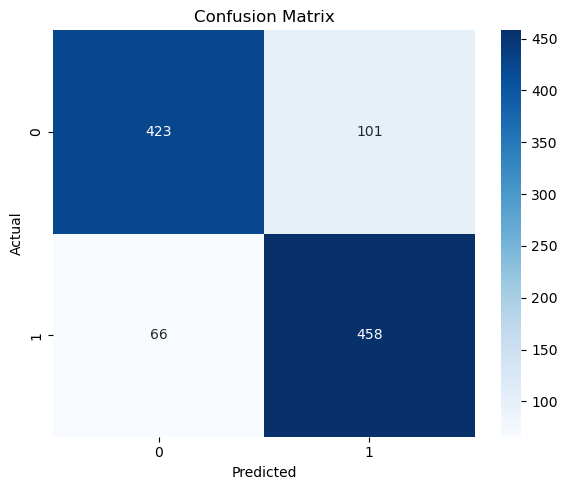

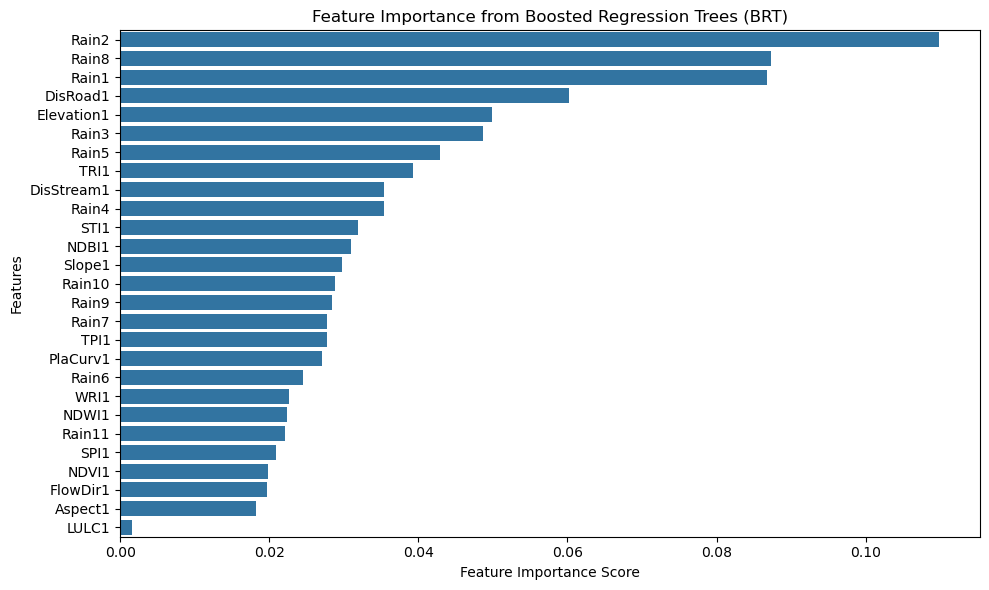

In [9]:
# ==== IMPORTS ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

# ==== DATA PREPARATION ====

# Define target column
target_column = "Target_Var"

# Shuffle and reset index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Fill missing values with zero
df = df.fillna(0)

# Define features and labels
X = df.drop(columns=[target_column, "wkt_geom"])
y = df[target_column]

# Display shapes
print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")

# ==== TRAIN-TEST SPLIT ====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ==== HYPERPARAMETER GRID ====
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

brt = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=brt,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# ==== RUN GRID SEARCH ====
grid_search.fit(X_train, y_train)

# Retrieve best model
best_model = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)

# ==== MAKE PREDICTIONS ====
y_pred = best_model.predict(X_test)

# ==== METRICS ====
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", report)

# ==== PLOT CONFUSION MATRIX ====
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ==== FEATURE IMPORTANCE PLOT ====
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance from Boosted Regression Trees (BRT)')
plt.tight_layout()
plt.show()


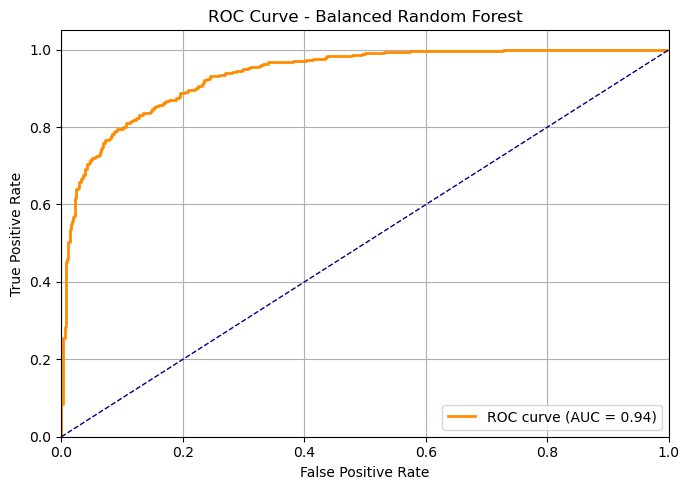

In [10]:
# ==== ROC CURVE FOR BINARY CLASSIFICATION ====
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_score = best_model.predict_proba(X_test)[:, 1]

# Compute False Positive Rate and True Positive Rate
fpr, tpr, _ = roc_curve(y_test, y_score)

# Compute AUC (Area Under Curve)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Balanced Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd

# Create DataFrame
df_brt = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Prob': y_score,         # Probabilities of class 1
    'Predicted_Label': y_pred          # Final predicted labels
})

# Save path
save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\BRT_Landslide_Results.csv"
df_brt.to_csv(save_path, index=False)


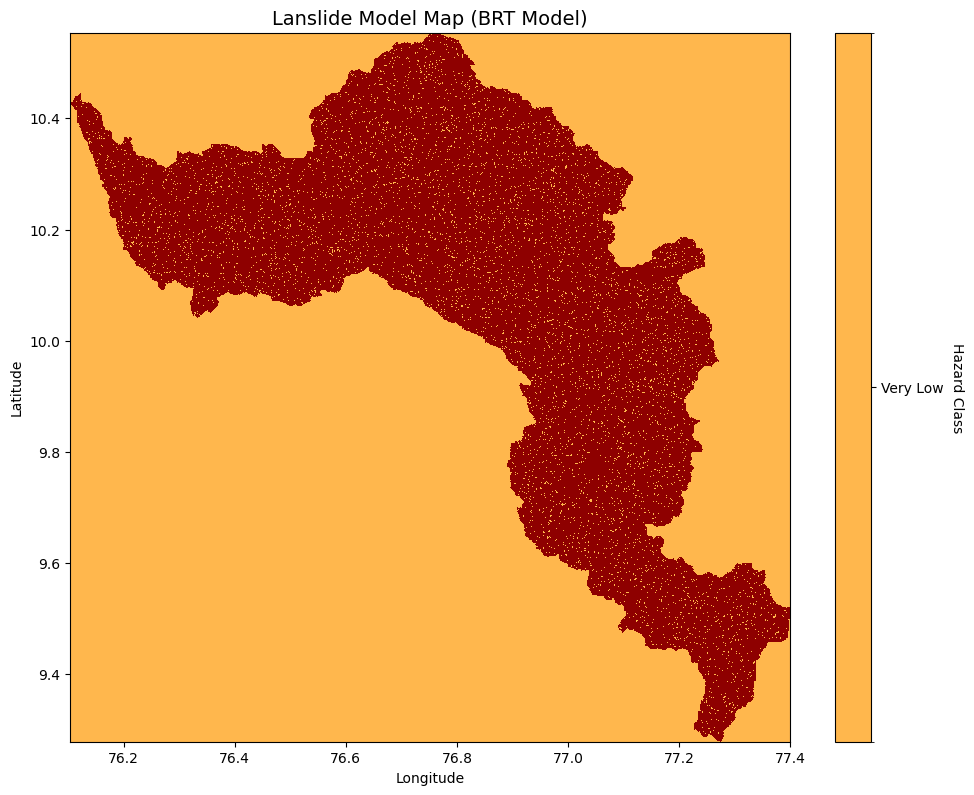

In [12]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import KBinsDiscretizer

# === STEP 1: Load Periyar Basin Shapefile ===
shapefile_path = r"C:\Users\megha\OneDrive - University of Twente\Desktop\Final\periyar.shp"
basin_gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# === STEP 2: Create Raster Grid ===
resolution = 0.001  # ~100m in lat/lon
minx, miny, maxx, maxy = basin_gdf.total_bounds
x_coords = np.arange(minx, maxx, resolution)
y_coords = np.arange(miny, maxy, resolution)
xx, yy = np.meshgrid(x_coords, y_coords)
grid_points = np.c_[xx.ravel(), yy.ravel()]
height, width = len(y_coords), len(x_coords)

# === STEP 3: Simulated Feature Matrix (Replace with actual features!) ===
n_features = 27
X_predict = np.random.rand(grid_points.shape[0], n_features)  # Dummy; replace with real features!

# === STEP 4: Predict Using Trained BRT Model ===
y_prob = best_model.predict_proba(X_predict)[:, 1]  # Probability of hazard presence

# === STEP 5: Classify into 5 Hazard Levels ===
# Quantile-based binning (alternative: strategy='kmeans', 'uniform')
binner = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
hazard_levels = binner.fit_transform(y_prob.reshape(-1, 1)).astype(int).flatten()

# Map to labels: 0→Very Low ... 4→Very High
hazard_labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
import matplotlib.colors as mcolors

# === COLOR SETTINGS BASED ON PAPER ===
hazard_labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

# Colors closely matching the paper's styling
custom_colors = ['#fff9c4',   # Very Low (light cream)
                 '#c5e1a5',   # Low (greenish yellow)
                 '#ffb74d',   # Moderate (orange)
                 '#e53935',   # High (red)
                 '#8e0000']   # Very High (dark maroon)

cmap = mcolors.ListedColormap(custom_colors)
bounds = [0, 1,] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# === STEP 6: Save as Raster ===
hazard_raster = hazard_levels.reshape((height, width))
transform = from_origin(minx, maxy, resolution, resolution)

temp_raster_path = "hazard_unclipped.tif"
with rasterio.open(
    temp_raster_path, "w", driver="GTiff", height=height, width=width, count=1,
    dtype=rasterio.uint8, crs="EPSG:4326", transform=transform
) as dst:
    dst.write(hazard_raster, 1)

# === STEP 7: Clip Raster to Periyar Basin ===
with rasterio.open(temp_raster_path) as src:
    out_image, out_transform = mask(src, basin_gdf.geometry, crop=True)
    out_meta = src.meta.copy()
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})
with rasterio.open("hazard_periyar_clipped.tif", "w", **out_meta) as dest:
    dest.write(out_image)

# === STEP 8: Plot Final Map ===
plt.figure(figsize=(10, 8))
im = plt.imshow(out_image[0], cmap=cmap, norm=norm, extent=[
    out_transform[2],
    out_transform[2] + out_transform[0] * out_image.shape[2],
    out_transform[5] + out_transform[4] * out_image.shape[1],
    out_transform[5]
])
plt.title("Lanslide Model Map (BRT Model)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5, 3.5, 4.5])
cbar.ax.set_yticklabels(hazard_labels)
cbar.set_label("Hazard Class", rotation=270, labelpad=15)
plt.grid(False)
plt.tight_layout()
plt.show()


## SHAP FOR BRT Landslide - Best Model From Comparison

In [14]:
! pip install shap imbalanced-learn pandas scikit-learn matplotlib seaborn

In [15]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# === Define model and paths ===
# brt_model: your trained Boosted Regression Trees model
# X_test: feature test set (no target column)

# Set your output directory
output_dir = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\SHAP\BRT"
os.makedirs(output_dir, exist_ok=True)

# === 1. SHAP TreeExplainer and SHAP value computation ===
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap_values.shape

# Save SHAP values
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
#shap_df.to_csv(os.path.join(output_dir, "shap_values_all_samples.csv"), index=False)
#shap_df




In [16]:
shap_values.shape

(1048, 27)

In [17]:
len(X_test)

1048

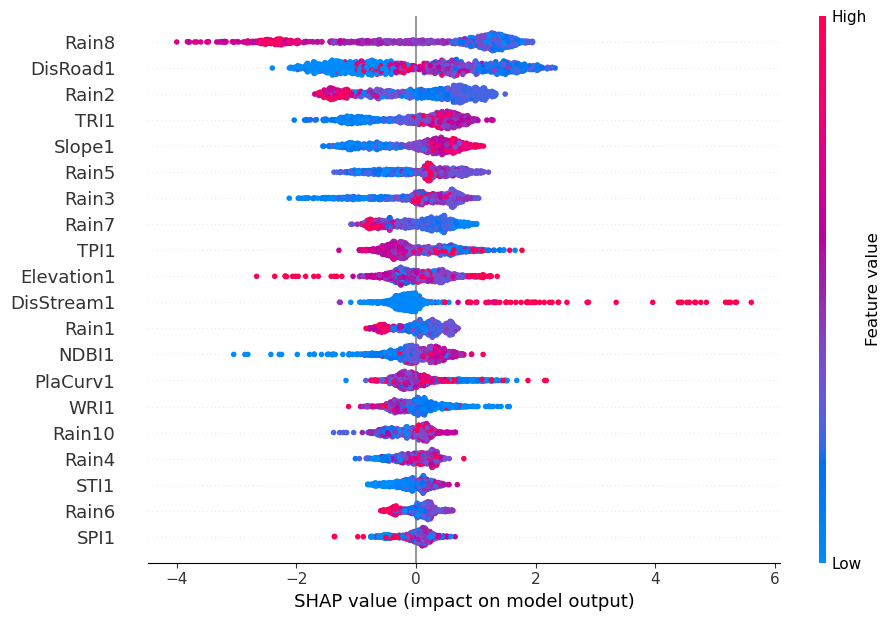

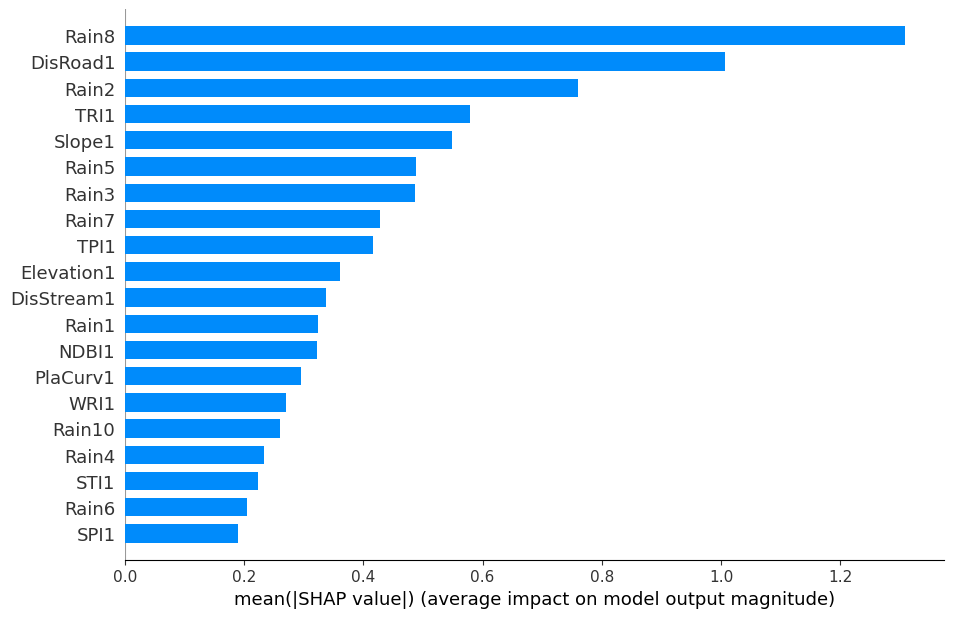

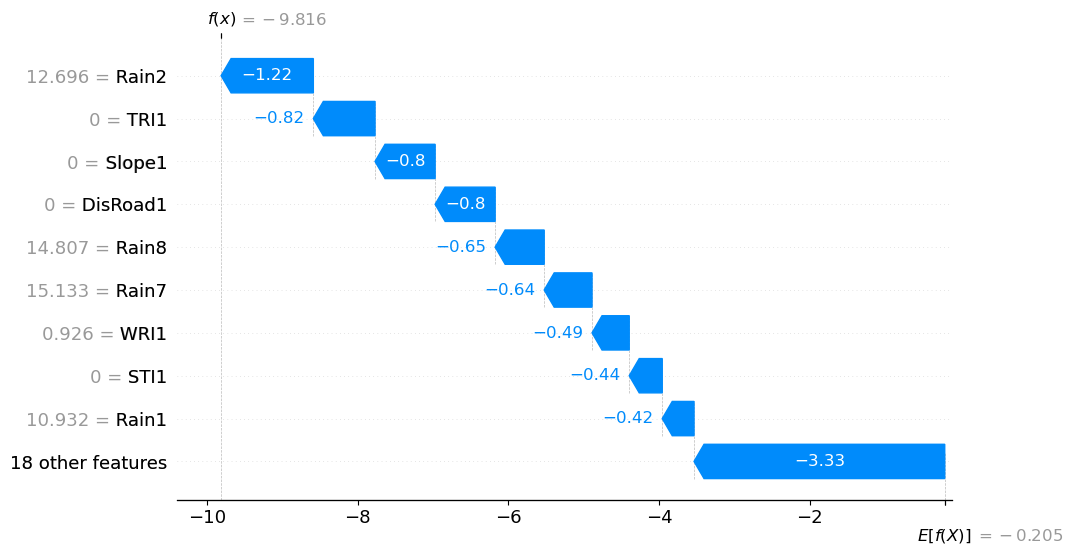

📊 Generating dependence plot for: Aspect1
⚠️ Skipped Aspect1: loop of ufunc does not support argument 0 of type Explanation which has no callable conjugate method
📊 Generating dependence plot for: Elevation1
⚠️ Skipped Elevation1: loop of ufunc does not support argument 0 of type Explanation which has no callable conjugate method
📊 Generating dependence plot for: NDBI1
⚠️ Skipped NDBI1: loop of ufunc does not support argument 0 of type Explanation which has no callable conjugate method
📊 Generating dependence plot for: NDVI1
⚠️ Skipped NDVI1: loop of ufunc does not support argument 0 of type Explanation which has no callable conjugate method
📊 Generating dependence plot for: NDWI1
⚠️ Skipped NDWI1: loop of ufunc does not support argument 0 of type Explanation which has no callable conjugate method
📊 Generating dependence plot for: TRI1
⚠️ Skipped TRI1: loop of ufunc does not support argument 0 of type Explanation which has no callable conjugate method
📊 Generating dependence plot for: 

In [18]:
# === 2. Global Feature Importance ===
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Absolute_SHAP': mean_abs_shap
}).sort_values(by='Mean_Absolute_SHAP', ascending=False)
shap_importance.to_csv(os.path.join(output_dir, "shap_global_importance.csv"), index=False)


shap.summary_plot(shap_values, X_test, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)
fig.savefig(os.path.join(output_dir, "summary_plot_beeswarm.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)
fig.savefig(os.path.join(output_dir, "summary_plot_bar.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# === 4. Force Plot (1st sample) ===
shap.initjs()
force_plot = shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])
shap.save_html(os.path.join(output_dir, "force_plot_sample_0.html"), force_plot)

# === 5. Waterfall Plot (1st sample) ===
if not isinstance(shap_values, shap.Explanation):
    shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0], show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)
fig.savefig(os.path.join(output_dir, "waterfall_plot_sample_0.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# === 6. Dependence Plots for All Features ===
for feature in X_test.columns:
    print(f"📊 Generating dependence plot for: {feature}")
    try:
        shap.dependence_plot(feature, shap_values, X_test, show=False)
        fig = plt.gcf()
        fig.set_size_inches(10, 6)
        fig.savefig(os.path.join(output_dir, f"dependence_plot_{feature}.png"), dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
    except Exception as e:
        print(f"⚠️ Skipped {feature}: {e}")
